# 1. PREPARATION

## 1.1. Read CSV

In [8]:
import pandas as pd


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)


df = pd.read_csv('data/dataset.new.csv')
display(df.head(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render
0,1,2015,South Korea,Visualization,Building,Religious,VR,HMD,3D Scanning;Modeling & Reconstruction,Laser Scanning;3D Modeling,Australis Photometric,Autodesk 3ds Max,Unity
1,2,2015,Spain,Reconstruction,Archaeological Site,LandBased,AR,Mobile,Image-Based Techniques;Modeling & Reconstruction,Photogrammetry;Structure from Motion (SfM);3D Modeling,Agisoft Metashape,Blender,NaN
2,3,2015,Peru,Visualization,Archaeological Site,LandBased,AR,Mobile,Image-Based Techniques,Photogrammetry;Structure from Motion (SfM),Agisoft Metashape,NaN,NaN


### 1.1.1. Add ZELEMÉR (#116)

In [9]:
my_project = {
    'order': 116,
    'year': 2026,
    'country': 'Hungary',
    'study_focus': 'Reconstruction',
    'historical_site_type': 'Building',
    'historical_site_type_sub': 'Religious',
    'platform': 'VR',
    'device': 'Mobile',
    'technique': 'Image-Based Techniques;Modeling & Reconstruction;Data Processing',
    'technique_sub': 'Image-Based Modeling (IBM);3D Modeling;Archaeological Interpretation',
    'software_data': '',
    'software_modeling': 'Autodesk AutoCAD;SketchUp',
    'software_render': 'Lumion'
}


df.loc[len(df)] = my_project
display(df.tail(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render
113,114,2025,Portugal,Restoration,Archaeological Site,LandBased,VR,HMD,Image-Based Techniques;Modeling & Reconstruction,Photogrammetry;3D Modeling,Agisoft Metashape,Blender,Unity
114,115,2025,Germany,Reconstruction,Building,Fortification,VR,HMD,Image-Based Techniques;Modeling & Reconstruction,Photogrammetry;3D Modeling,Agisoft Metashape,Meshlab,Unity
115,116,2026,Hungary,Reconstruction,Building,Religious,VR,Mobile,Image-Based Techniques;Modeling & Reconstruction;Data Processing,Image-Based Modeling (IBM);3D Modeling;Archaeological Interpretation,,Autodesk AutoCAD;SketchUp,Lumion


## 1.2. Tokenize Dataset

In [3]:
def get_multi_value_columns(df):
    multi_value_columns = []
    
    for col in df.columns:
        if df[col].dropna().astype(str).str.contains(";").any():
            multi_value_columns.append(col)
            
    return multi_value_columns


multi_value_columns = get_multi_value_columns(df)
print(*multi_value_columns, sep="\n")

platform
device
technique
technique_sub
software_data
software_modeling
software_render


In [4]:
def tokenize_columns(df, columns_to_tokenize):
    for col in columns_to_tokenize:
        df[col] = df[col].fillna("").apply(
            lambda x: [item.strip() for item in str(x).split(";") if item.strip()]
        )
        
    return df


df_tokenized = tokenize_columns(df, multi_value_columns)
display(df_tokenized.tail(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render
113,114,2025,Portugal,Restoration,Archaeological Site,LandBased,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Blender],[Unity]
114,115,2025,Germany,Reconstruction,Building,Fortification,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Meshlab],[Unity]
115,116,2026,Hungary,Reconstruction,Building,Religious,[VR],[Mobile],"[Image-Based Techniques, Modeling & Reconstruction, Data Processing]","[Image-Based Modeling (IBM), 3D Modeling, Archaeological Interpretation]",[],"[Autodesk AutoCAD, SketchUp]",[Lumion]


## 1.3. Add ÉLŐ Scores

In [10]:
ELOS =  [
    1349, 1581, 1544, 1505, 1596, 1231, 1393, 1198, 1232, 1646, 
    1377, 1550, 1492, 1577, 1286, 1199, 1771, 1669, 1320, 1441, 
    1431, 1520, 1574, 1426, 1304, 1401, 1305, 1683, 1272, 1428, 
    1488, 1691, 1908, 1556, 1406, 1509, 1379, 1557, 1471, 1751, 
    1775, 1491, 1463, 1386, 1633, 1566, 1497, 1330, 1497, 1408, 
    1461, 1812, 1298, 1388, 1626, 1657, 1472, 1337, 1483, 1491, 
    1559, 1310, 1522, 1442, 1421, 1575, 1670, 1619, 1288, 1364, 
    1655, 1728, 1442, 1381, 1537, 1493, 1464, 1460, 1665, 1388, 
    1741, 1643, 1603, 1285, 1537, 1687, 1544, 1449, 1581, 1537, 
    1673, 1497, 1434, 1585, 1579, 1450, 1263, 1578, 1568, 1425, 
    1663, 1477, 1233, 1448, 1460, 1342, 1674, 1545, 1600, 1266, 
    1608, 1742, 1596, 1446, 1708, 1439
]

df_tokenized['elo'] = ELOS
df_elos_added = df_tokenized
display(df_elos_added.tail(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render,elo
113,114,2025,Portugal,Restoration,Archaeological Site,LandBased,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Blender],[Unity],1446
114,115,2025,Germany,Reconstruction,Building,Fortification,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Meshlab],[Unity],1708
115,116,2026,Hungary,Reconstruction,Building,Religious,[VR],[Mobile],"[Image-Based Techniques, Modeling & Reconstruction, Data Processing]","[Image-Based Modeling (IBM), 3D Modeling, Archaeological Interpretation]",[],"[Autodesk AutoCAD, SketchUp]",[Lumion],1439


## 1.4. Summary

In [6]:
def get_column_statistics(df, column_name, is_list):
    total_rows = len(df)
    stats = []
    
    if is_list:
        all_items = []
        for lst in df[column_name].dropna():
            if isinstance(lst, list):
                all_items.extend(lst)
        unique_labels = sorted(list(set(all_items)))
    else:
        unique_labels = sorted(df[column_name].dropna().unique().tolist())
        
    for label in unique_labels:
        if is_list:
            count = df[column_name].apply(lambda x: label in x if isinstance(x, list) else False).sum()
        else:
            count = (df[column_name] == label).sum()
            
        percent = round((count / total_rows) * 100, 1)
        stats.append((label, count, percent))
        
    return stats


def print_formatted_table(column_name, stats, w_name, w_count, w_pct):
    print("\n")
    print(f"{column_name:<{w_name}} | {'count':<{w_count}} | {'percent':<{w_pct}}")
    print("─" * 70)

    for label, count, percent in stats:
        percent_str = f"{percent}%"
        print(f"{str(label):<{w_name}} | {str(count):<{w_count}} | {percent_str:<{w_pct}}")


def print_dataset_summary(df, multi_value_columns, w_name=40, w_count=10, w_pct=10):
    ignore_columns = ['order', 'year', 'country', 'elo']
        
    for col in df.columns:
        if col in ignore_columns:
            continue
            
        is_list = col in multi_value_columns
        stats = get_column_statistics(df, col, is_list)
        print_formatted_table(col, stats, w_name, w_count, w_pct)


print_dataset_summary(df_elos_added, multi_value_columns)



study_focus                              | count      | percent   
──────────────────────────────────────────────────────────────────────
Reconstruction                           | 48         | 41.4%     
Restoration                              | 9          | 7.8%      
Visualization                            | 59         | 50.9%     


historical_site_type                     | count      | percent   
──────────────────────────────────────────────────────────────────────
Archaeological Site                      | 55         | 47.4%     
Artistic Feature                         | 6          | 5.2%      
Building                                 | 49         | 42.2%     
Natural Space                            | 6          | 5.2%      


historical_site_type_sub                 | count      | percent   
──────────────────────────────────────────────────────────────────────
ArchitecturalAsset                       | 2          | 1.7%      
Artifact                                 | 4

# 2. K-MEAN

## 2.1. Elbow Method

Calculated K_MAX: 8 (for N=116)

k (Clusters) | Inertia
------------------------------
1            | 2,426,836.44
2            | 826,788.27
3            | 417,329.32
4            | 223,339.69
5            | 167,705.20
6            | 103,130.16
7            | 83,013.40


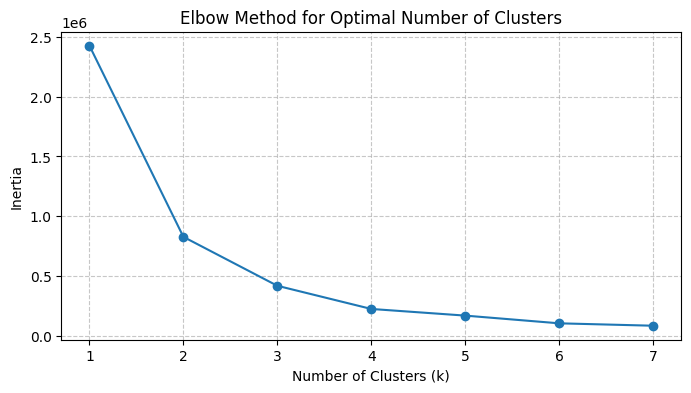

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


def plot_elbow_method(elos, k_max, random_state):
    X = np.array(elos).reshape(-1, 1)
    k_values = list(range(1, k_max))
    
    inertias = []
    for k in k_values:
        k_mean = KMeans(n_clusters=k, random_state=random_state).fit(X)
        inertias.append(k_mean.inertia_)

    print(f"\n{'k (Clusters)':<12} | {'Inertia'}")
    print("-" * 30)
    for k, val in zip(k_values, inertias):
        print(f"{k:<12} | {val:,.2f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, inertias, marker="o")
    plt.xticks(k_values)
    plt.title("Elbow Method for Optimal Number of Clusters")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    return plt


N     = len(ELOS)
K_MAX = int(round(np.sqrt(N / 2)))
print(f"Calculated K_MAX: {K_MAX} (for N={N})")

RANDOM_STATE = 42
PATH_PLOT    = 'data/K_MEAN.png'

plt = plot_elbow_method(ELOS, K_MAX, RANDOM_STATE)
plt.savefig(PATH_PLOT)
plt.show()

## 2.2. Davies-Bouldin Method


k (Clusters) | Score
------------------------------
2            | 0.59329
3            | 0.54647
4            | 0.49531
5            | 0.51001
6            | 0.48700
7            | 0.47329


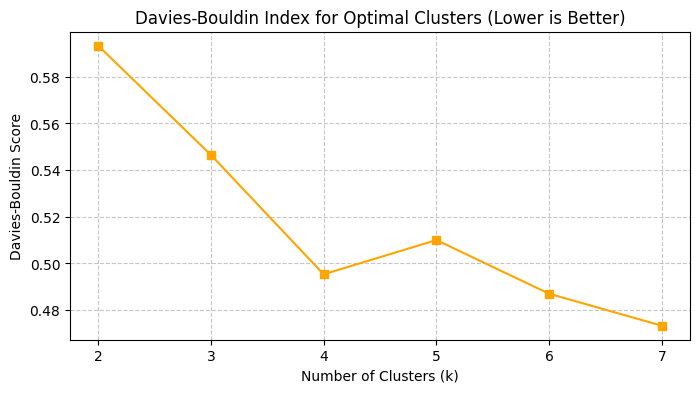

In [8]:
from sklearn.metrics import davies_bouldin_score


def plot_davies_bouldin(elos, k_max, random_state):
    X = np.array(elos).reshape(-1, 1)
    k_values = list(range(2, k_max))
    
    dbscores = []
    for k in k_values:
        k_mean = KMeans(n_clusters=k, random_state=random_state).fit(X)
        score = davies_bouldin_score(X, k_mean.labels_)
        dbscores.append(score)

    print(f"\n{'k (Clusters)':<12} | {'Score'}")
    print("-" * 30)
    for k, val in zip(k_values, dbscores):
        print(f"{k:<12} | {val:,.5f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, dbscores, marker="s", color="orange")
    plt.xticks(k_values)
    plt.title("Davies-Bouldin Index for Optimal Clusters (Lower is Better)")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Davies-Bouldin Score")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    return plt


PATH_PLOT_DB = 'data/DAVIES_BOULDIN.png'

plt_db = plot_davies_bouldin(ELOS, K_MAX, RANDOM_STATE)
plt_db.savefig(PATH_PLOT_DB)
plt_db.show()

# 3. CLUSTERING

In [9]:
from sklearn.cluster import KMeans


def add_elo_clusters(df, k, random_state):
    df_clustered = df.copy()
    X = df_clustered[['elo']]
    
    km = KMeans(n_clusters=k, random_state=random_state)
    km.fit(X)
    
    centers = km.cluster_centers_.flatten()
    order = centers.argsort()
    remap = {original_label: new_label + 1 for new_label, original_label in enumerate(order)}
    
    df_clustered['cluster'] = [f"cluster_{remap[label]}" for label in km.labels_]
    
    return df_clustered


K            = 4
RANDOM_STATE = 42
df_clustered = add_elo_clusters(df_elos_added, K, RANDOM_STATE)

print(f"\n{'CLUSTER':<12} | {'MIN ELO':<10} | {'MAX ELO':<10} | {'COUNT'}")
print("-" * 50)
summary = df_clustered.groupby('cluster')['elo'].agg(['min', 'max', 'count'])
for cluster, row in summary.iterrows():
    print(f"{cluster:<12} | {row['min']:<10} | {row['max']:<10} | {row['count']}")
print("\n")

display(df_clustered.tail(3))


CLUSTER      | MIN ELO    | MAX ELO    | COUNT
--------------------------------------------------
cluster_1    | 1198       | 1349       | 20
cluster_2    | 1364       | 1497       | 42
cluster_3    | 1505       | 1633       | 32
cluster_4    | 1643       | 1908       | 22




,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render,elo,cluster
113,114,2025,Portugal,Restoration,Archaeological Site,LandBased,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Blender],[Unity],1446,cluster_2
114,115,2025,Germany,Reconstruction,Building,Fortification,[VR],[HMD],"[Image-Based Techniques, Modeling & Reconstruction]","[Photogrammetry, 3D Modeling]",[Agisoft Metashape],[Meshlab],[Unity],1708,cluster_4
115,116,2026,Hungary,Reconstruction,Building,Religious,[VR],[Mobile],"[Image-Based Techniques, Modeling & Reconstruction, Data Processing]","[Image-Based Modeling (IBM), 3D Modeling, Archaeological Interpretation]",[],"[Autodesk AutoCAD, SketchUp]",[Lumion],1439,cluster_2


# 4. ONE-HOT

## 4.1. Create Binary Dataset

In [13]:
import re


def format_column_names(original_column_name, dummy_columns):
    prefix = "".join([word[0] for word in original_column_name.split('_') if word])
    
    new_columns = {}
    for val in dummy_columns:
        clean_val = re.sub(r'[^a-z0-9]+', '_', str(val).lower()).strip('_')
        new_columns[val] = f"{prefix}_{clean_val}"
        
    return new_columns


def encode_single_column(df, column_name, is_multi_value):
    if is_multi_value:
        joined_strings = df[column_name].apply(lambda x: '|'.join(x) if isinstance(x, list) else "")
        return joined_strings.str.get_dummies(sep='|')
    else:
        return pd.get_dummies(df[column_name], dtype=int)


def create_df_binary(df, multi_value_columns):
    ignore_columns = ['order', 'year', 'country', 'elo', 'cluster']
    encoded_frames = []
    
    for col in df.columns:
        if col in ignore_columns:
            continue
            
        is_multi_value = col in multi_value_columns
        df_encoded     = encode_single_column(df, col, is_multi_value)
        new_names      = format_column_names(col, df_encoded.columns)
        df_encoded     = df_encoded.rename(columns=new_names)
        
        encoded_frames.append(df_encoded)

    return pd.concat(encoded_frames, axis=1)


df_binary = create_df_binary(df_clustered, multi_value_columns)
print(df_binary.shape[1])
display(df_binary.head(3))

128


,sf_reconstruction,sf_restoration,sf_visualization,hst_archaeological_site,hst_artistic_feature,hst_building,hst_natural_space,hsts_architecturalasset,hsts_artifact,hsts_cave,hsts_fortification,hsts_landbased,hsts_religious,hsts_underwater,hsts_urbanspace,p_ar,p_mr,p_vr,p_xr,d_hmd,d_immersive_display,d_mobile,d_pc,t_3d_scanning,t_data_processing,t_geospatial_techniques,t_image_based_techniques,t_modeling_reconstruction,ts_3d_modeling,ts_3d_texturing,ts_archaeological_interpretation,ts_bim,ts_beacon_localization,ts_digital_elevation_models_dem,ts_geographic_information_system_gis,ts_global_navigation_satellite_system_gnss,ts_hbim,ts_hdr_imaging,ts_image_based_modeling_ibm,ts_laser_scanning,ts_multi_view_stereo_mvs,ts_photogrammetry,ts_rgb_d_imaging,ts_range_based_modeling_rbm,ts_real_time_volumetric_capture,ts_semantic_data_extraction,ts_spherical_imaging,ts_stratigraphic_mapping,ts_structure_from_motion_sfm,ts_texture_mapping,ts_uav_aerial_imaging,ts_virtual_anastylosis,ts_visual_inertial_slam,sd_3df_zephyr,sd_affinity,sd_agisoft_metashape,sd_arcgis,sd_arcmap,sd_australis_photometric,sd_autodesk_meshmixer,sd_autodesk_mudbox,sd_autodesk_recap,sd_catia,sd_cloudcompare,sd_contextcapture,sd_dstretch,sd_dynamo,sd_faro_scene,sd_focus_scene,sd_graphos,sd_leica_cyclone,sd_matlab,sd_mesh_buildup_wizard,sd_mongodb,sd_mysql,sd_pix4d_capture,sd_ptgui,sd_polycam,sd_postgis,sd_postgresql,sd_processing,sd_qgis,sd_reality_capture,sd_riegl_riscan,sd_trimble_business_center,sd_trimble_realworks,sd_world_creator_2,sm_3dreshaper,sm_archicad,sm_autodesk_3ds_max,sm_autodesk_autocad,sm_autodesk_fusion_360,sm_autodesk_maya,sm_autodesk_remake,sm_autodesk_revit,sm_blender,sm_fuente_nueva,sm_geomagic,sm_maxon_cinema4d,sm_meshlab,sm_meshmixer,sm_ramsete,sm_rhinoceros,sm_simlab,sm_sketchup,sm_zbrush,sr_arkit,sr_augment,sr_d5_render,sr_easyar,sr_enscape,sr_fb360_encoder,sr_gimp,sr_kolor_panotour,sr_lumion,sr_maxwhere,sr_middlevr,sr_pano2vr,sr_renderman,sr_shapespark,sr_sketchfab,sr_three_js,sr_twinmotion,sr_unity,sr_unreal_engine,sr_v_ray,sr_verge3d,sr_vuforia
0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4.2. Find MIN_FREQ

Calculated MIN_FREQ: 11

BIN RANGE            | FEATURE COUNT
-----------------------------------
1.00 - 4.43          | 79
4.43 - 7.87          | 12
7.87 - 11.30         | 4
11.30 - 14.73        | 8
14.73 - 18.17        | 4
18.17 - 21.60        | 0
21.60 - 25.03        | 2
25.03 - 28.47        | 0
28.47 - 31.90        | 1
31.90 - 35.33        | 1
35.33 - 38.77        | 1
38.77 - 42.20        | 0
42.20 - 45.63        | 0
45.63 - 49.07        | 3
49.07 - 52.50        | 1
52.50 - 55.93        | 3
55.93 - 59.37        | 2
59.37 - 62.80        | 2
62.80 - 66.23        | 0
66.23 - 69.67        | 1
69.67 - 73.10        | 0
73.10 - 76.53        | 0
76.53 - 79.97        | 0
79.97 - 83.40        | 0
83.40 - 86.83        | 0
86.83 - 90.27        | 0
90.27 - 93.70        | 0
93.70 - 97.13        | 1
97.13 - 100.57       | 2
100.57 - 104.00      | 1




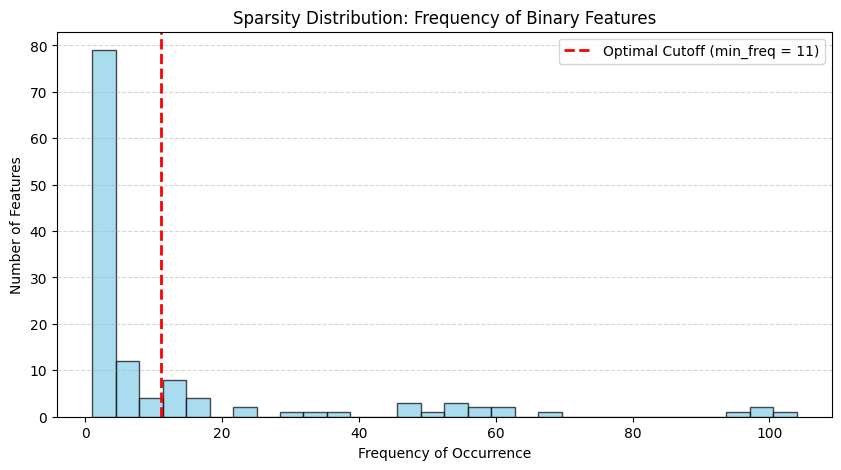

In [47]:
def calculate_optimal_min_freq(frequencies, bins=30):
    counts, bin_edges = np.histogram(frequencies, bins=bins)
    
    trough_idx = 0
    for i in range(1, len(counts) - 1):
        if counts[i] <= counts[i-1] and counts[i] < counts[i+1]:
            trough_idx = i
            break
            
    return int(round(bin_edges[trough_idx + 1]))


def plot_sparsity_distribution(frequencies, threshold, bins=30):
    plt.figure(figsize=(10, 5))
    n, bin_edges, _ = plt.hist(frequencies, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Optimal Cutoff (min_freq = {threshold})')
    plt.title("Sparsity Distribution: Frequency of Binary Features")
    plt.xlabel("Frequency of Occurrence")
    plt.ylabel("Number of Features")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    print(f"\n{'BIN RANGE':<20} | {'FEATURE COUNT'}")
    print("-" * 35)
    for i in range(len(n)):
        bin_label = f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}"
        print(f"{bin_label:<20} | {int(n[i])}")
    print("\n")
    
    return plt


feature_frequencies = df_binary.sum()

MIN_FREQ = calculate_optimal_min_freq(feature_frequencies)
print(f"Calculated MIN_FREQ: {MIN_FREQ}")

PATH_PLOT_SPARSITY = 'data/SPARSITY.png'
plt_sparsity = plot_sparsity_distribution(feature_frequencies, MIN_FREQ)
plt_sparsity.savefig(PATH_PLOT_SPARSITY)
plt_sparsity.show()

## 4.3. Filter Rare Binaries

In [48]:
def filter_rare_features(df_binary, min_freq):
    frequencies       = df_binary.sum()
    valid_columns     = frequencies[frequencies >= min_freq].index
    df_rares_filtered = df_binary[valid_columns].copy()
    
    return df_rares_filtered


df_rares_filtered = filter_rare_features(df_binary, MIN_FREQ)
display(df_rares_filtered.tail(3))


print(f"Total binary features    : {df_binary.shape[1]}")
print(f"Dropped binary features  : {df_binary.shape[1] - df_rares_filtered.shape[1]}")
print(f"Remaining binary features: {df_rares_filtered.shape[1]}")

,sf_reconstruction,sf_visualization,hst_archaeological_site,hst_building,hsts_fortification,hsts_landbased,hsts_religious,hsts_urbanspace,p_ar,p_vr,d_hmd,d_mobile,d_pc,t_3d_scanning,t_geospatial_techniques,t_image_based_techniques,t_modeling_reconstruction,ts_3d_modeling,ts_geographic_information_system_gis,ts_hbim,ts_laser_scanning,ts_photogrammetry,ts_structure_from_motion_sfm,ts_uav_aerial_imaging,sd_agisoft_metashape,sd_autodesk_recap,sd_leica_cyclone,sm_autodesk_3ds_max,sm_autodesk_autocad,sm_autodesk_revit,sm_blender,sr_unity,sr_unreal_engine
113,0,0,1,0,0,1,0,0,0,1,1,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0
114,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
115,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


Total binary features    : 128
Dropped binary features  : 95
Remaining binary features: 33


## 4.4. Summary

In [49]:
def print_binary_summary(df_binary, w_name=45, w_count=10, w_pct=10): 
    header = f"{'FEATURE':<{w_name}} | {'COUNT':<{w_count}} | {'PERCENT':<{w_pct}}"
    print(header)
    print("─" * len(header))

    total_rows = len(df_binary)
    frequencies = df_binary.sum().sort_values(ascending=False)
    
    for feature, count in frequencies.items():
        percent_str = f"{round((count / total_rows) * 100, 1)}%"
        print(f"{str(feature):<{w_name}} | {str(count):<{w_count}} | {percent_str:<{w_pct}}")


# print_dataset_summary(df_rares_filtered, [])
print_binary_summary(df_rares_filtered)

FEATURE                                       | COUNT      | PERCENT   
───────────────────────────────────────────────────────────────────────
t_image_based_techniques                      | 104        | 89.7%     
ts_photogrammetry                             | 99         | 85.3%     
p_vr                                          | 99         | 85.3%     
d_hmd                                         | 96         | 82.8%     
t_modeling_reconstruction                     | 68         | 58.6%     
sr_unity                                      | 61         | 52.6%     
sd_agisoft_metashape                          | 60         | 51.7%     
sf_visualization                              | 59         | 50.9%     
t_3d_scanning                                 | 56         | 48.3%     
hst_archaeological_site                       | 55         | 47.4%     
ts_3d_modeling                                | 55         | 47.4%     
ts_laser_scanning                             | 53         | 45.

# 5. TRAIN/TEST

In [50]:
from sklearn.model_selection import train_test_split


def prepare_train_test_split(X_features, original_df, test_size=0.20, random_state=42):
    y = original_df['cluster']
    X = X_features.copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y # 4 clusters are even!
    )
    
    print(f"{'METRIC':<10} | {'TOTAL':<10} | {'TRAIN':<10} | {'TEST':<10}")
    print("-" * 50)
    print(f"{'Samples':<10} | {len(X):<10} | {len(X_train):<10} | {len(X_test):<10}")
    print(f"{'Features':<10} | {X.shape[1]:<10} | {X_train.shape[1]:<10} | {X_test.shape[1]:<10}")
    print("\n")
    
    print(f"{'CLUSTER':<10} | {'TOTAL':<10} | {'TRAIN':<10} | {'TEST':<10}")
    print("-" * 50)
    train_counts = y_train.value_counts().sort_index()
    test_counts  = y_test.value_counts().sort_index()
    for cluster in train_counts.index:
        train_val = train_counts.get(cluster, 0)
        test_val  = test_counts.get(cluster, 0)
        total_val = train_val + test_val
        print(f"{cluster:<10} | {total_val:<10} | {train_val:<10} | {test_val:<10}")
        
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = prepare_train_test_split(df_rares_filtered, df_clustered)

METRIC     | TOTAL      | TRAIN      | TEST      
--------------------------------------------------
Samples    | 116        | 92         | 24        
Features   | 33         | 33         | 33        


CLUSTER    | TOTAL      | TRAIN      | TEST      
--------------------------------------------------
cluster_1  | 20         | 16         | 4         
cluster_2  | 42         | 33         | 9         
cluster_3  | 32         | 25         | 7         
cluster_4  | 22         | 18         | 4         


# 6. f_score & p_value

In [96]:
import pandas as pd
from sklearn.feature_selection import f_classif


def analyze_feature_significance(X_train, y_train):
    f_scores, p_values = f_classif(X_train, y_train)
      
    df_stats = pd.DataFrame({
        'feature': X_train.columns,
        'count'  : X_train.sum().values,
        'f_score': f_scores,
        'p_value': p_values
    })
    
    df_stats['significant (p<0.05)'] = df_stats['p_value'] < 0.05
    df_stats['f_score'] = df_stats['f_score'].apply(lambda x: f"{x:.2f}")
    df_stats['p_value'] = df_stats['p_value'].apply(lambda x: f"{x:.4f}")
    df_stats = df_stats.sort_values(by='p_value', ascending=True).reset_index(drop=True)
    
    return df_stats


print(f"Feature Significance Analysis (Training Data N={len(X_train)}):")
print('-'*80)
df_significance = analyze_feature_significance(X_train, y_train)
display(df_significance)

Feature Significance Analysis (Training Data N=92):
--------------------------------------------------------------------------------


,feature,count,f_score,p_value,significant (p<0.05)
0,p_vr,81,3.28,0.0247,True
1,ts_photogrammetry,78,2.74,0.0483,True
2,sd_leica_cyclone,12,2.73,0.0484,True
3,sd_agisoft_metashape,48,1.97,0.1243,False
4,d_mobile,36,1.89,0.1373,False
5,hst_building,39,1.89,0.1376,False
6,t_image_based_techniques,83,1.88,0.1396,False
7,hsts_fortification,9,1.71,0.1703,False
8,sf_visualization,46,1.68,0.1778,False
9,ts_uav_aerial_imaging,14,1.34,0.2666,False


# 7. MACHINE LEARNING

## 7.1. 80/20 Test

In [94]:
from sklearn.naive_bayes    import GaussianNB
from sklearn.linear_model   import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier

from sklearn.metrics        import accuracy_score
import time,warnings


MODELS = [
    ('Naive Bayes (Gaussian)'                  , GaussianNB()),
    ('Logistic Regression (ridge)'             , LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
    ('Deep Neural Network (two hidden layers)' , MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)),
    ('Decision Tree (CART)'                    , DecisionTreeClassifier(random_state=42)),
    ('Random Forest (100 trees)'               , RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Support Vector Machine (RBF Kernel)'     , SVC(kernel='rbf', random_state=42)),
    ('k-Nearest Neighbors'                     , KNeighborsClassifier()),
]


def train_models(models_list, X_train, y_train, X_test, y_test):
    trained_models = {}
    
    for name, model in models_list:
        start_time = time.perf_counter()
        
        model.fit(X_train, y_train)
        y_predictions = model.predict(X_test)

        end_time = time.perf_counter()
        run_time = end_time - start_time
        accuracy = accuracy_score(y_test, y_predictions)
        
        trained_models[name] = {
            'model'      : model,
            'predictions': y_predictions,
            'accuracy'   : accuracy,
            'run_time'   : run_time
        }

    return trained_models


def print_model_leaderboard(trained_models):
    print(f"\n{'MACHINE LEARNING MODELS':<40} | {'ACCURACY':<10} | {'RUN TIME':<10}")
    print("-" * 80)
    
    for name, data in trained_models.items():
        accuracy = data['accuracy']
        run_time = data['run_time']
        print(f"{name:<40} | {accuracy * 100:>7.2f}%   | {run_time:>7.4f}s")


results_dict = train_models(MODELS, X_train, y_train, X_test, y_test)
print_model_leaderboard(results_dict)


MACHINE LEARNING MODELS                  | ACCURACY   | RUN TIME  
--------------------------------------------------------------------------------
Naive Bayes (Gaussian)                   |   25.00%   |  0.0031s
Logistic Regression (ridge)              |   29.17%   |  0.0137s
Deep Neural Network (two hidden layers)  |   25.00%   |  0.1839s
Decision Tree (CART)                     |   25.00%   |  0.0028s
Random Forest (100 trees)                |   25.00%   |  0.0972s
Support Vector Machine (RBF Kernel)      |   25.00%   |  0.0023s
k-Nearest Neighbors                      |   33.33%   |  0.0026s


## 7.2. Cross Validate

In [101]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


def cross_validate_models(models_list, X, y, splits=5):
    cv_results = {}
    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)
    
    for name, model in models_list:
        start_time    = time.perf_counter()
        scores        = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
        end_time      = time.perf_counter()
        
        cv_results[name] = {
            'accuracy': np.mean(scores),
            'scores'  : scores,
            'run_time': end_time - start_time
        }
        
    return cv_results


def print_cv_leaderboard(cv_results):
    print(f"\n{'MACHINE LEARNING MODELS':<40} | {'CV ACCURACY':<19} | {'RUN TIME':<10}")
    print("-" * 80)
       
    for name, data in cv_results.items():
        acc = data['accuracy']
        rt  = data['run_time']
        std = np.std(data['scores'])
        print(f"{name:<40} | {acc * 100:>6.2f}% (+/- {std * 100:>4.1f}%) | {rt:>7.4f}s")


X_full          = df_rares_filtered.copy()
y_full          = df_clustered['cluster']
cv_results_dict = cross_validate_models(MODELS, X_full, y_full)
print_cv_leaderboard(cv_results_dict)


MACHINE LEARNING MODELS                  | CV ACCURACY         | RUN TIME  
--------------------------------------------------------------------------------
Naive Bayes (Gaussian)                   |  23.26% (+/-  7.5%) |  0.0167s
Logistic Regression (ridge)              |  30.22% (+/-  5.0%) |  0.0716s
Deep Neural Network (two hidden layers)  |  31.12% (+/-  6.7%) |  0.7491s
Decision Tree (CART)                     |  32.75% (+/- 11.5%) |  0.0169s
Random Forest (100 trees)                |  31.01% (+/- 10.0%) |  0.6347s
Support Vector Machine (RBF Kernel)      |  32.79% (+/-  3.7%) |  0.0287s
k-Nearest Neighbors                      |  22.39% (+/-  3.0%) |  0.0159s
